In [1]:
!pip install kagglehub --upgrade

In [2]:
import kagglehub

/home/ujjwal/ujjwal/Hybrid-Recommender-system/recom-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#download the dataset form kaggle 
kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

'/home/ujjwal/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1'

In [4]:
import os 
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [5]:
data_path = Path('/home/ujjwal/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1')

songs_data_path = data_path/ 'Music Info.csv'
users_data_path= data_path/ 'User Listening History.csv'

In [26]:
# songs_data

songs_df = pd.read_csv(songs_data_path, usecols=["track_id","name","artist","spotify_preview_url"])

songs_df.shape

(50683, 4)

import 

In [7]:
import dask.dataframe as dd

# Load the dataset
df = dd.read_csv(users_data_path)

# Check the first few rows to verify the data
df.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [11]:
df.npartitions #number of partition 

9

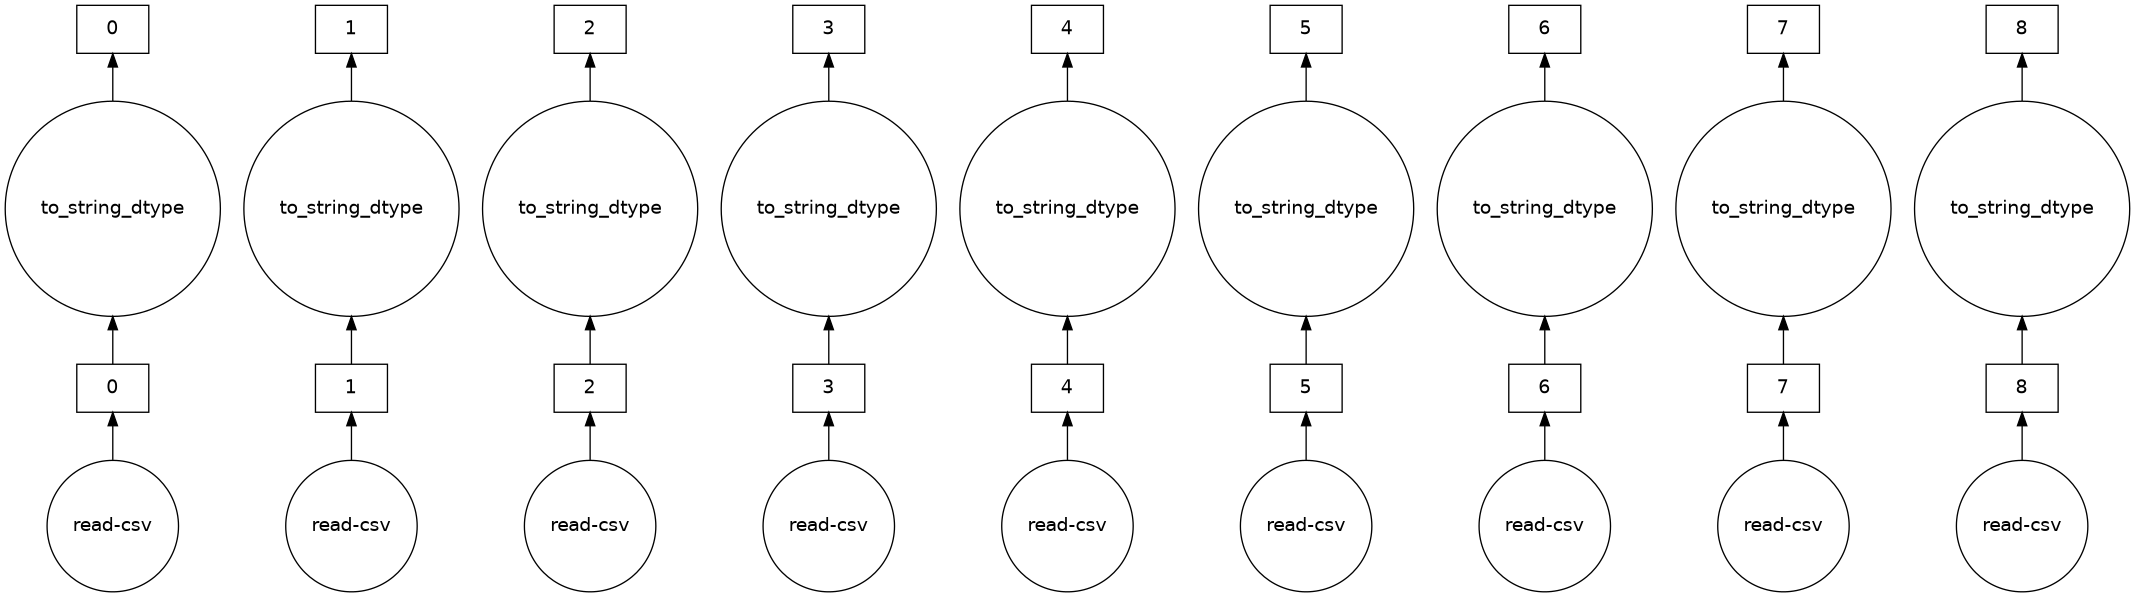

In [16]:
df.visualize(tasks=True)

In [17]:
df.columns

Index(['track_id', 'user_id', 'playcount'], dtype='object')

In [31]:
# number of unique tracks in the data

unique_tracks = df.loc[:,"track_id"].nunique()

unique_tracks_numbers = unique_tracks.compute()

unique_tracks_numbers

np.int64(30459)

In [34]:
## unique tracks id 
unique_tracks_ids= df.loc[: , "track_id"].unique().compute()
unique_tracks_ids= unique_tracks_ids.tolist()
unique_tracks_ids[:5]

['TRLXSNR128F429361D',
 'TRPUGUW128F426BF6F',
 'TRISTWT128F1488FBB',
 'TRKPWGR128E078EE06',
 'TRXQJWK128F146DF76']

In [21]:
# number of unique users in the data

unique_users = df.loc[:,"user_id"].nunique()

unique_users = unique_users.compute()

unique_users

np.int64(962037)

In [29]:
unique_tracks

np.int64(30459)

In [43]:
#filtered songs 
filtered_songs= songs_df[songs_df['track_id'].isin(unique_tracks_ids)]

filtered_songs.reset_index(drop = True , inplace = True)
filtered_songs

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
3,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...
4,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...
...,...,...,...,...
30454,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,https://p.scdn.co/mp3-preview/8b3d529025fe3c60...
30455,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,https://p.scdn.co/mp3-preview/cf64490291f9a600...
30456,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...
30457,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...


In [45]:
filtered_songs[filtered_songs["name"] == "Colors Of The Wind"] 

,track_id,name,artist,spotify_preview_url
30457,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...
